In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
df_processed = pd.read_pickle("dataframes/df_processed.pkl")

In [3]:
crime_codes = {
    'ICCS0101': 'Intentional homicide',
    'ICCS0301': 'Sexual violence',
    'ICCS03011': 'Rape',
    'ICCS0401': 'Robbery',
    'ICCS0502': 'Theft',
}

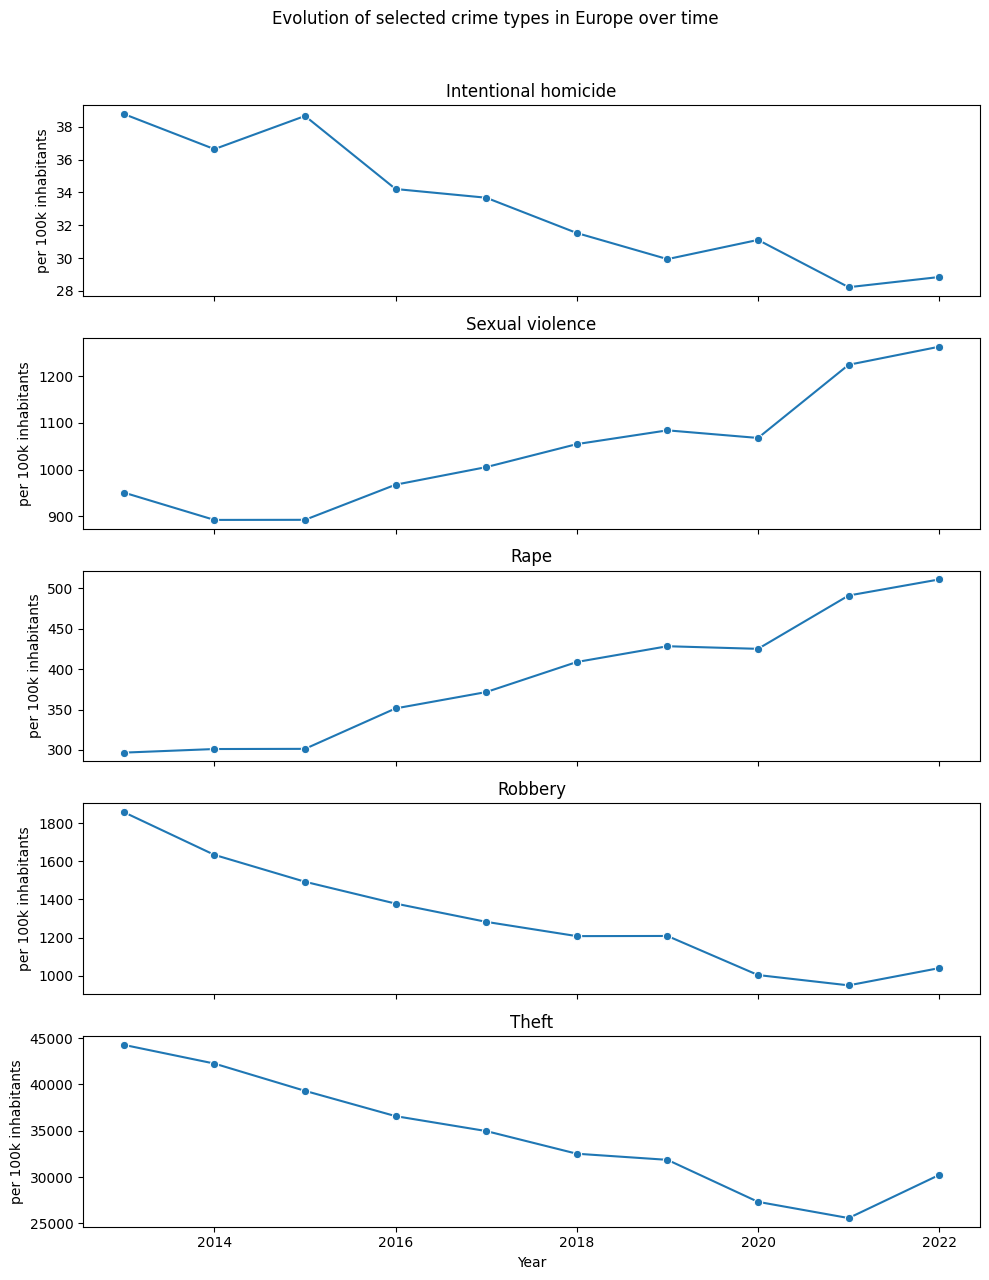

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Europe-wide totals (sums across all countries) per year on demand
numeric_cols = [
    c for c in df_processed.select_dtypes(include="number").columns
    if c != "year"
 ]
df_totals = (
    df_processed
    .groupby("year")[numeric_cols]
    .sum()
    .reset_index()
 )

# Keep only year and selected crime-code columns
crime_cols = list(crime_codes.keys())
cols_for_plot = ["year"] + crime_cols
df_eu_subset = df_totals[cols_for_plot].copy()

# Reshape to long format: one row per (year, crime code)
df_eu_long = df_eu_subset.melt(
    id_vars="year",
    value_vars=crime_cols,
    var_name="iccs",
    value_name="crime_rate_per_100k"
 )

# Map ICCS codes to descriptive crime names for nicer labels
df_eu_long["crime_type"] = df_eu_long["iccs"].map(crime_codes)

# Create 5 subplots, one for each crime type
unique_crimes = crime_cols
n_crimes = len(unique_crimes)
fig, axes = plt.subplots(n_crimes, 1, figsize=(10, 2.5 * n_crimes), sharex=True)

# If only one crime, axes may not be an array
if n_crimes == 1:
    axes = [axes]

for ax, iccs_code in zip(axes, unique_crimes):
    crime_name = crime_codes.get(iccs_code, iccs_code)
    data_sub = df_eu_long[df_eu_long["iccs"] == iccs_code]
    sns.lineplot(
        data=data_sub,
        x="year",
        y="crime_rate_per_100k",
        marker="o",
        ax=ax,
    )
    ax.set_title(crime_name)
    ax.set_ylabel("per 100k inhabitants")

axes[-1].set_xlabel("Year")
plt.suptitle("Evolution of selected crime types in Europe over time", y=1.02)
plt.tight_layout()
plt.show()

In [5]:
from scipy import stats

# Filter to years 2013 & 2022
df_pair = df_processed.copy()
df_pair = df_pair[df_pair["year"].isin([2013, 2022])]

# Pivot so each row is a country, columns are years, values are crime_per_100k
pivot = (
    df_pair
    .pivot_table(index="country", columns="year", values="crime_per_100k")
    .dropna(subset=[2013, 2022])
)

crime_2013 = pivot[2013]
crime_2022 = pivot[2022]

# Paired t-test (2022 vs 2013, per country)
t_stat, p_val = stats.ttest_rel(crime_2022, crime_2013)
mean_diff = (crime_2022 - crime_2013).mean()

print("Paired T-Test for crime_per_100k (2022 vs 2013)")
print(f"Number of countries used: {len(pivot)}")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.4f}")
print(f"Mean difference (2022 - 2013): {mean_diff:.4f}")

if p_val < 0.05:
    print("RESULT: SIGNIFICANT CHANGE")
else:
    print("RESULT: NO SIGNIFICANT CHANGE")

Paired T-Test for crime_per_100k (2022 vs 2013)
Number of countries used: 27
T-statistic: -5.0394
P-value: 0.0000
Mean difference (2022 - 2013): -531.4896
RESULT: SIGNIFICANT CHANGE


In [6]:
from scipy import stats

alpha = 0.01  # 99% confidence level

# We test these ICCS codes with directional hypotheses
codes_expect_decrease = [
    'ICCS0101',  # Intentional homicide
    'ICCS0401',  # Robbery
    'ICCS0502',  # Theft (and subcategories)
 ]
codes_expect_increase = [
    'ICCS0301',   # Sexual violence
    'ICCS03011',  # Rape
 ]

# Use country-level data for 2013 and 2022 (df_processed has no TOTAL rows here)
df_pair_all = df_processed.copy()
df_pair_all = df_pair_all[df_pair_all["year"].isin([2013, 2022])]

def run_directional_paired_test(iccs_code: str, expect: str):
    label = crime_codes.get(iccs_code, iccs_code)
    sub = df_pair_all[["country", "year", iccs_code]].dropna()
    if sub.empty:
        print(f"{label} ({iccs_code}): no data available.")
        return

    pivot = (
        sub
        .pivot(index="country", columns="year", values=iccs_code)
        .dropna(subset=[2013, 2022])
    )

    vals_2013 = pivot[2013]
    vals_2022 = pivot[2022]

    t_stat, p_val_two_sided = stats.ttest_rel(vals_2022, vals_2013)
    mean_diff = (vals_2022 - vals_2013).mean()  # 2022 - 2013
    p_val_one_sided = p_val_two_sided / 2 if p_val_two_sided is not None else None

    if expect == "decrease":
        significant = (p_val_one_sided is not None) and (p_val_one_sided < alpha) and (mean_diff < 0)
        direction_text = "expected LOWER in 2022"
    else:  # expect == "increase"
        significant = (p_val_one_sided is not None) and (p_val_one_sided < alpha) and (mean_diff > 0)
        direction_text = "expected HIGHER in 2022"

    print(f"\nPaired T-Test for {label} ({iccs_code}) – {direction_text}")
    print(f"Countries used: {len(pivot)}")
    print(f"Mean 2013: {vals_2013.mean():.3f}")
    print(f"Mean 2022: {vals_2022.mean():.3f}")
    print(f"Mean diff (2022 - 2013): {mean_diff:.3f}")
    print(f"T-statistic: {t_stat:.4f}")
    print(f"Two-sided p-value: {p_val_two_sided:.4f}")
    print(f"One-sided p-value: {p_val_one_sided:.4f}")
    if significant:
        print("RESULT: SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)")
    else:
        print("RESULT: NO SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)")

# Run tests for each ICCS code with its expected direction
for code in codes_expect_decrease:
    run_directional_paired_test(code, expect="decrease")

for code in codes_expect_increase:
    run_directional_paired_test(code, expect="increase")


Paired T-Test for Intentional homicide (ICCS0101) – expected LOWER in 2022
Countries used: 27
Mean 2013: 1.436
Mean 2022: 1.069
Mean diff (2022 - 2013): -0.368
T-statistic: -2.1636
Two-sided p-value: 0.0399
One-sided p-value: 0.0199
RESULT: NO SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)

Paired T-Test for Robbery (ICCS0401) – expected LOWER in 2022
Countries used: 27
Mean 2013: 68.838
Mean 2022: 38.493
Mean diff (2022 - 2013): -30.345
T-statistic: -6.1500
Two-sided p-value: 0.0000
One-sided p-value: 0.0000
RESULT: SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)

Paired T-Test for Theft (ICCS0502) – expected LOWER in 2022
Countries used: 27
Mean 2013: 1640.034
Mean 2022: 1119.765
Mean diff (2022 - 2013): -520.269
T-statistic: -4.8277
Two-sided p-value: 0.0001
One-sided p-value: 0.0000
RESULT: SIGNIFICANT CHANGE in the expected direction (alpha = 0.01)

Paired T-Test for Sexual violence (ICCS0301) – expected HIGHER in 2022
Countries used: 27
Mean 2013: 35.216

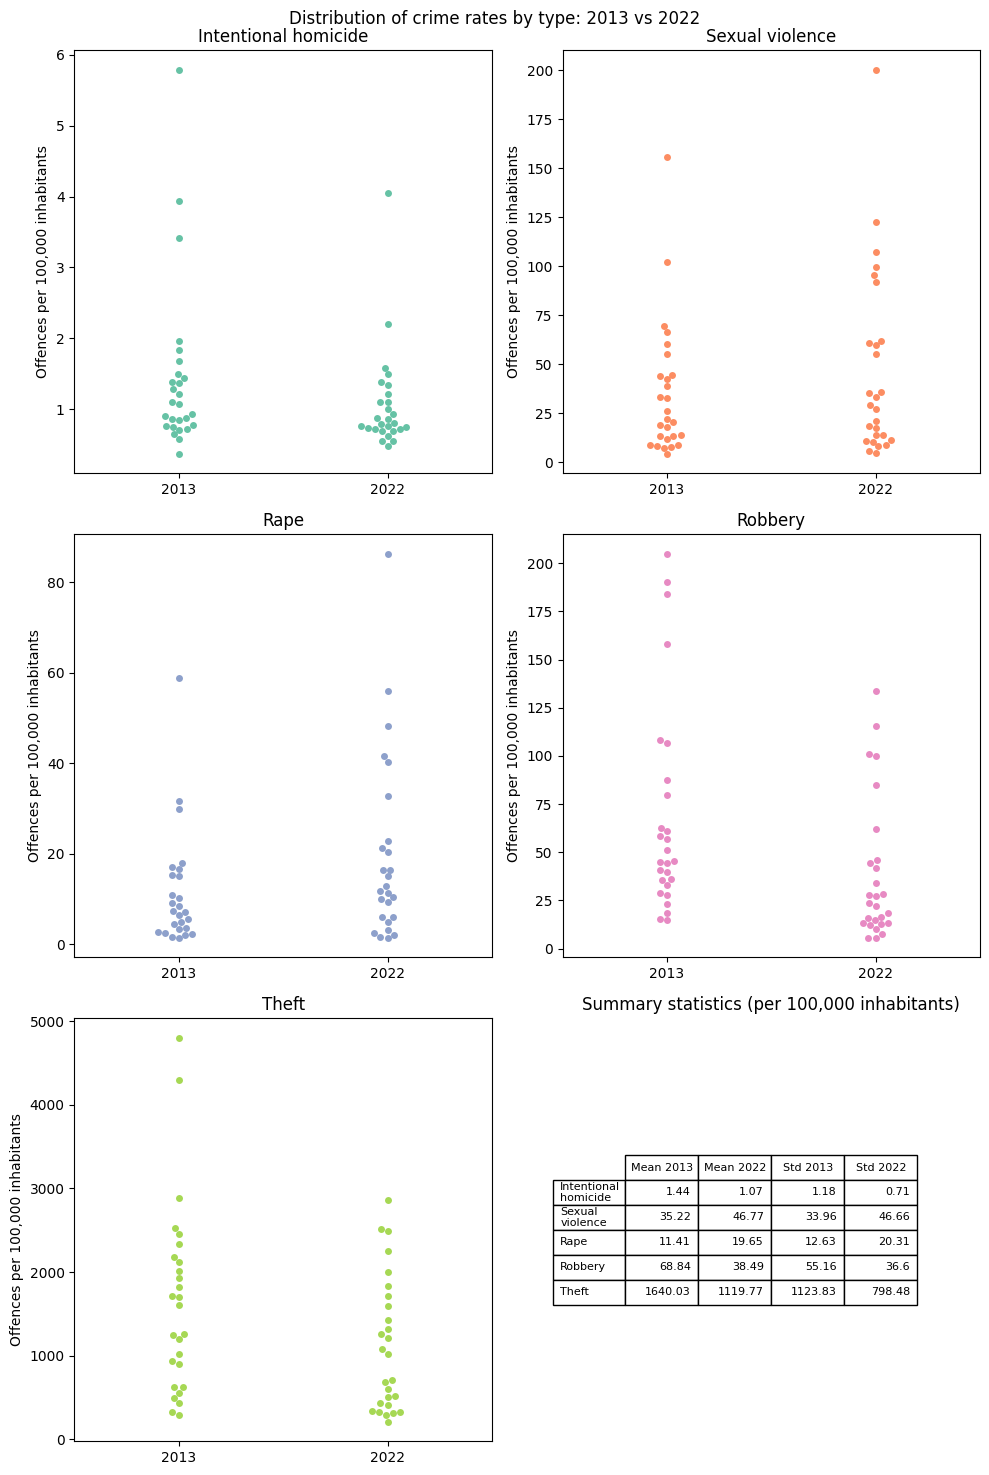

In [7]:
# Boxplots of decade shift (2013 vs 2022) for each crime type
# Filter to data for 2013 and 2022
df_box = df_processed.copy()
df_box = df_box[df_box["year"].isin([2013, 2022])]

crime_cols = list(crime_codes.keys())

# Reshape to long format: one row per (country, year, crime code) with its value
df_box_long = df_box.melt(
    id_vars=["country", "year"],
    value_vars=crime_cols,
    var_name="iccs",
    value_name="crime_rate_per_100k"
 )

# Map to readable crime names
df_box_long["crime_type"] = df_box_long["iccs"].map(crime_codes)

# Define plotting order of crimes based on crime_codes
crime_order = [crime_codes[c] for c in crime_cols]

# Define distinct colors for each crime subplot
colors = sns.color_palette("Set2", len(crime_order))

# Create a 3x2 grid of subplots: 5 for boxplots, 1 for summary table
fig, axes = plt.subplots(3, 2, figsize=(10, 15), sharex=False)
axes_flat = axes.flatten()

# First 5 subplots: boxplots per crime type, each with its own color
for i, crime_name in enumerate(crime_order):
    ax = axes_flat[i]
    data_sub = df_box_long[df_box_long["crime_type"] == crime_name]
    sns.swarmplot(
        data=data_sub,
        x="year",
        y="crime_rate_per_100k",
        ax=ax,
        color=colors[i],
    )
    ax.set_title(crime_name)
    ax.set_xlabel("")  # no x-axis label
    ax.set_ylabel("Offences per 100,000 inhabitants")

# Last subplot: table with summary statistics
table_ax = axes_flat[-1]
table_ax.axis("off")

stats_rows = []
for crime_name in crime_order:
    data_2013 = df_box_long[(df_box_long["crime_type"] == crime_name) & (df_box_long["year"] == 2013)]["crime_rate_per_100k"]
    data_2022 = df_box_long[(df_box_long["crime_type"] == crime_name) & (df_box_long["year"] == 2022)]["crime_rate_per_100k"]
    stats_rows.append({
        "Crime": crime_name,
        "Mean 2013": data_2013.mean(),
        "Mean 2022": data_2022.mean(),
        "Std 2013": data_2013.std(),
        "Std 2022": data_2022.std(),
    })

df_stats = pd.DataFrame(stats_rows)
df_stats_round = df_stats.copy()
df_stats_round.iloc[:, 1:] = df_stats_round.iloc[:, 1:].round(2)

# Shorter column labels to keep table compact
col_labels = ["Mean 2013", "Mean 2022", "Std 2013", "Std 2022"]

# Row labels with manual line breaks for selected crimes
row_labels = df_stats_round["Crime"].replace({
    "Intentional homicide": "Intentional\nhomicide",
    "Sexual violence": "Sexual\nviolence",
})

table = table_ax.table(
    cellText=df_stats_round.iloc[:, 1:].values,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(0.7, 1.2)
table_ax.set_title("Summary statistics (per 100,000 inhabitants)")

plt.suptitle("Distribution of crime rates by type: 2013 vs 2022", y=0.98)
plt.tight_layout()
plt.show()

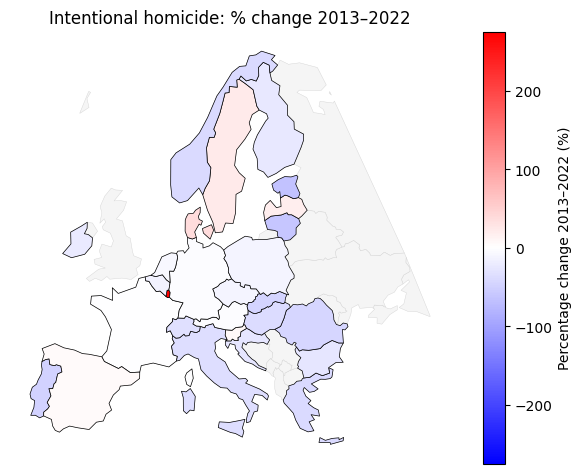

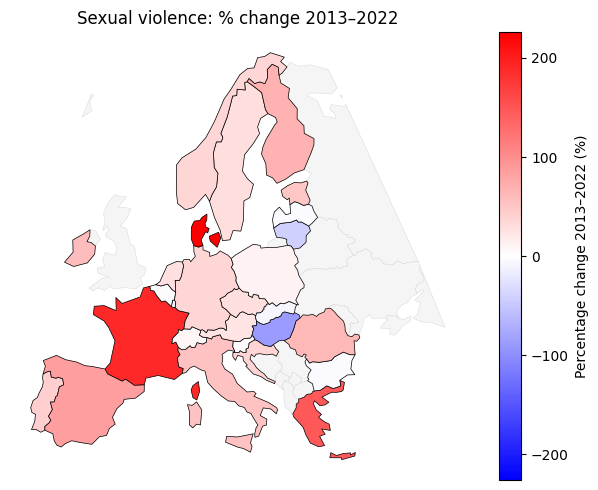

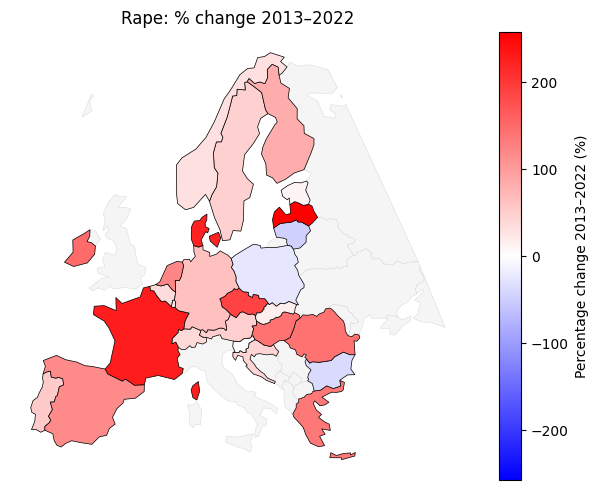

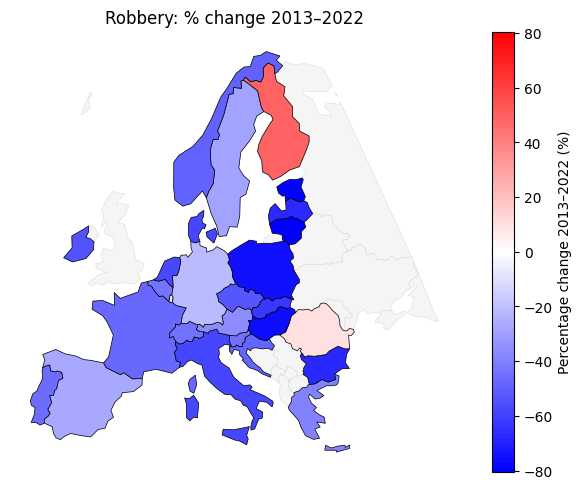

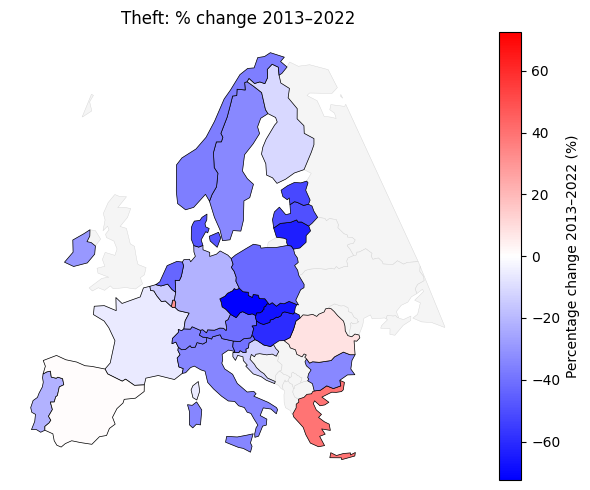

In [8]:
# 6. Europe maps: decade absolute shift per crime (2013 → 2022, per 100k inhabitants)

import geopandas as gpd
from shapely.geometry import box
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

# Ensure we have df_processed and crime_codes from earlier cells
# df_processed: country-level data with crime-code columns per 100k and a 'year' column
crime_cols = list(crime_codes.keys())

# Restrict to the start and end year of the decade
start_year = 2013
end_year = 2022
df_decade = df_processed[df_processed["year"].isin([start_year, end_year])].copy()

# Pivot to get one row per country, columns = (crime_code, year)
pivot = df_decade.pivot_table(index="country", columns="year", values=crime_cols)

# Separate start and end year values
vals_start = pivot.xs(start_year, level="year", axis=1)
vals_end = pivot.xs(end_year, level="year", axis=1)

# Compute absolute change for each crime code per country: end - start (per 100k inhabitants)
delta = vals_end - vals_start

# Load and prepare Europe geometries (Natural Earth admin-0)
url = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)
europe = world[world["CONTINENT"] == "Europe"].copy()

# Clip to a Europe bounding box in lon/lat
europe_bbox = box(-15, 30, 40, 72)
europe = gpd.clip(europe, europe_bbox)

# Reproject to a Europe-friendly projected CRS (ETRS89 / LAEA Europe)
europe_laea = europe.to_crs(epsg=3035)

# Diverging colormap: negative (blue) → zero (white) → positive (red)
bwr_cmap = LinearSegmentedColormap.from_list("blue_white_red", ["blue", "white", "red"])

for iccs_code in crime_cols:
    crime_name = crime_codes.get(iccs_code, iccs_code)
    # Build a DataFrame with absolute change for this crime
    df_delta = delta[[iccs_code]].rename(columns={iccs_code: "delta_per_100k"}).reset_index()

    # Merge with Europe geometries
    gdf = europe_laea.merge(df_delta, left_on="NAME", right_on="country", how="left")

    # Determine symmetric color scale around 0 for this crime
    max_abs = np.nanmax(np.abs(gdf["delta_per_100k"]))
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1.0

    fig, ax = plt.subplots(figsize=(7, 5))
    # Light background for all European countries
    gdf.plot(ax=ax, color="whitesmoke", edgecolor="lightgrey", linewidth=0.3)
    # Overlay only countries with available change
    gdf.dropna(subset=["delta_per_100k"]).plot(
        column="delta_per_100k",
        ax=ax,
        cmap=bwr_cmap,
        vmin=-max_abs,
        vmax=max_abs,
        edgecolor="black",
        linewidth=0.5,
        legend=True,
        legend_kwds={"label": "Change {}–{} (per 100k)".format(start_year, end_year)},
    )
    ax.set_title(f"{crime_name}: change {start_year}–{end_year} (per 100k)")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

In [11]:
display(df_processed[(df_processed['geo'] == 'CZ') & (df_processed['year'] == 2013)])
display(df_processed[(df_processed['geo'] == 'CZ') & (df_processed['year'] == 2022)])

,geo,year,asylum_applicants,population,asylum_per_100k,country,ICCS0101,ICCS0301,ICCS03011,ICCS0401,ICCS0502,crime_per_100k
40,CZ,2013,500.0,10516125.0,4.754603,Czechia,0.86,13.47,5.6,29.01,1200.28,1249.22


,geo,year,asylum_applicants,population,asylum_per_100k,country,ICCS0101,ICCS0301,ICCS03011,ICCS0401,ICCS0502,crime_per_100k
49,CZ,2022,1335.0,10516707.0,12.694088,Czechia,0.75,17.32,16.29,13.52,330.65,378.53
